In [45]:
import pandas as pd

df = pd.read_csv("DataSet_distillation.csv")
print(df.head())
print(df.info())

   Run  RefluxRatio  BottomFlow  Feed Temperature  CondenserDuty  \
0  1.0          2.0        13.9              78.0        1644.00   
1  2.0          2.5        13.9              78.0        1917.01   
2  3.0          3.0        13.9              78.0        2189.90   
3  4.0          3.5        13.9              78.0        2462.78   
4  5.0          4.0        13.9              78.0        2735.68   

   ReboilerDuty  EthanolPurity  WaterBottom  
0      -1646.00          0.780        0.780  
1      -1918.64          0.787        0.787  
2      -2191.38          0.792        0.792  
3      -2464.16          0.796        0.796  
4      -2736.97          0.800        0.800  
<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Run               36 non-null     float64
 1   RefluxRatio       36 non-null     float64
 2   BottomFlow        36 non-null  

In [46]:
print(df.isnull().sum())

Run                 1
RefluxRatio         1
BottomFlow          1
Feed Temperature    1
CondenserDuty       1
ReboilerDuty        1
EthanolPurity       1
WaterBottom         1
dtype: int64


In [47]:
df = df.dropna()

In [48]:
df = df.astype(float)

In [49]:
print(df.columns)

Index(['Run', 'RefluxRatio', 'BottomFlow', 'Feed Temperature', 'CondenserDuty',
       'ReboilerDuty', 'EthanolPurity', 'WaterBottom'],
      dtype='str')


In [50]:
X = df[['RefluxRatio', 'BottomFlow', 'Feed Temperature']]
y = df['ReboilerDuty']

In [51]:
X = X.dropna()
y = y.loc[X.index]

In [52]:
from sklearn.model_selection import train_test_split

# This creates X_train, X_test, y_train, and y_test in your computer's memory
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [54]:
from sklearn.metrics import r2_score, mean_squared_error

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

R2 Score: 0.7048940201168111
MSE: 206000.26114476283


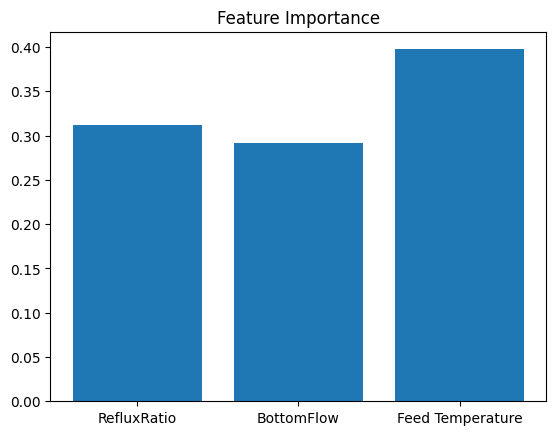

In [55]:
import matplotlib.pyplot as plt

plt.bar(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.show()

In [58]:
sample = [[3, 14, 80]]  # RR, BottomFlow, FeedTemp
print(model.predict(sample))

[-2223.75335]


c:\Users\PROBOOK\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [59]:
import pandas as pd

sample = pd.DataFrame([{
    "RefluxRatio": 3,
    "BottomFlow": 14,
    "Feed Temperature": 80
}])

print(model.predict(sample))

[-2223.75335]
